Crear un predictor de `Life expectancy` utilizando las columnas que considere apropiadas.

# NOTAS:

- Primer modelo con datos generales, eliminando años, vamos a tener problemas de independencia de datos.
- Cuando creemos el siguiente modelo vamos a recuperar los datos con los años y proceder a crear un nuevo modelo empleando los años.

In [160]:
import pandas as pd

# https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
df = pd.read_csv('..\Sources\Ejercicios\Life Expectancy Data.csv')
print('Datos cargados correctamente')

Datos cargados correctamente


In [161]:
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [162]:
df.columns = df.columns.str.strip() # eliminamos espacios en blanco de los nombres de las columnas
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [163]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 1. EDA

Vamos a empezra con el EDA. En este apartado vamos a ver el tipo de datos que tenemos, si hay valores ausentes y la correlación de datos.

In [164]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [165]:
print(f'Forma: {df.shape}')
print(f'Valores nulos:\n{df.isnull().sum()}')

Forma: (2938, 22)
Valores nulos:
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


Comprobamos que hay bastantes valores ausentes. El mejor método de imputación tal vez sea un MICE.

In [166]:
df.describe().round(2)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70


In [167]:
df.Country.value_counts()

Country
Afghanistan              16
Peru                     16
Nicaragua                16
Niger                    16
Nigeria                  16
                         ..
Niue                      1
San Marino                1
Nauru                     1
Saint Kitts and Nevis     1
Dominica                  1
Name: count, Length: 193, dtype: int64

Antes de realizar la matriz de correlaciones para ver el comportamiento de las variables, teniendo en cuenta que tenemos valores ausentes, vamos a proceder a la imputación mediante el método MICE. Este método procede a iterar n veces para calcular los resultados de los valores que se encuentran ausentes.

In [168]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Separamos la columna categórica Status antes de imputar

status = df['Status']
country = df['Country']
df_numeric = df.drop(columns=['Status', 'Country'])

# Procedemos a imputar
imputer = IterativeImputer(random_state=0, max_iter=10)

df_imputed = pd.DataFrame( # lo convertimos en DataFrame
    imputer.fit_transform(df_numeric), # entrenamos el imputador con los datos numéricos
    columns=df_numeric.columns
)

# Volvemos a añadir la columna Status al DataFrame imputado
df_imputed['Status'] = status.values
df_imputed['Country'] = country.values

# Verificamos que no hay valores nulos
print(df_imputed.isnull().sum())

Year                               0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
Status                             0
Country                            0
dtype: int64


Una vez realicada la imputación de datos, podemos comprobar que ya no quedan valores ausentes

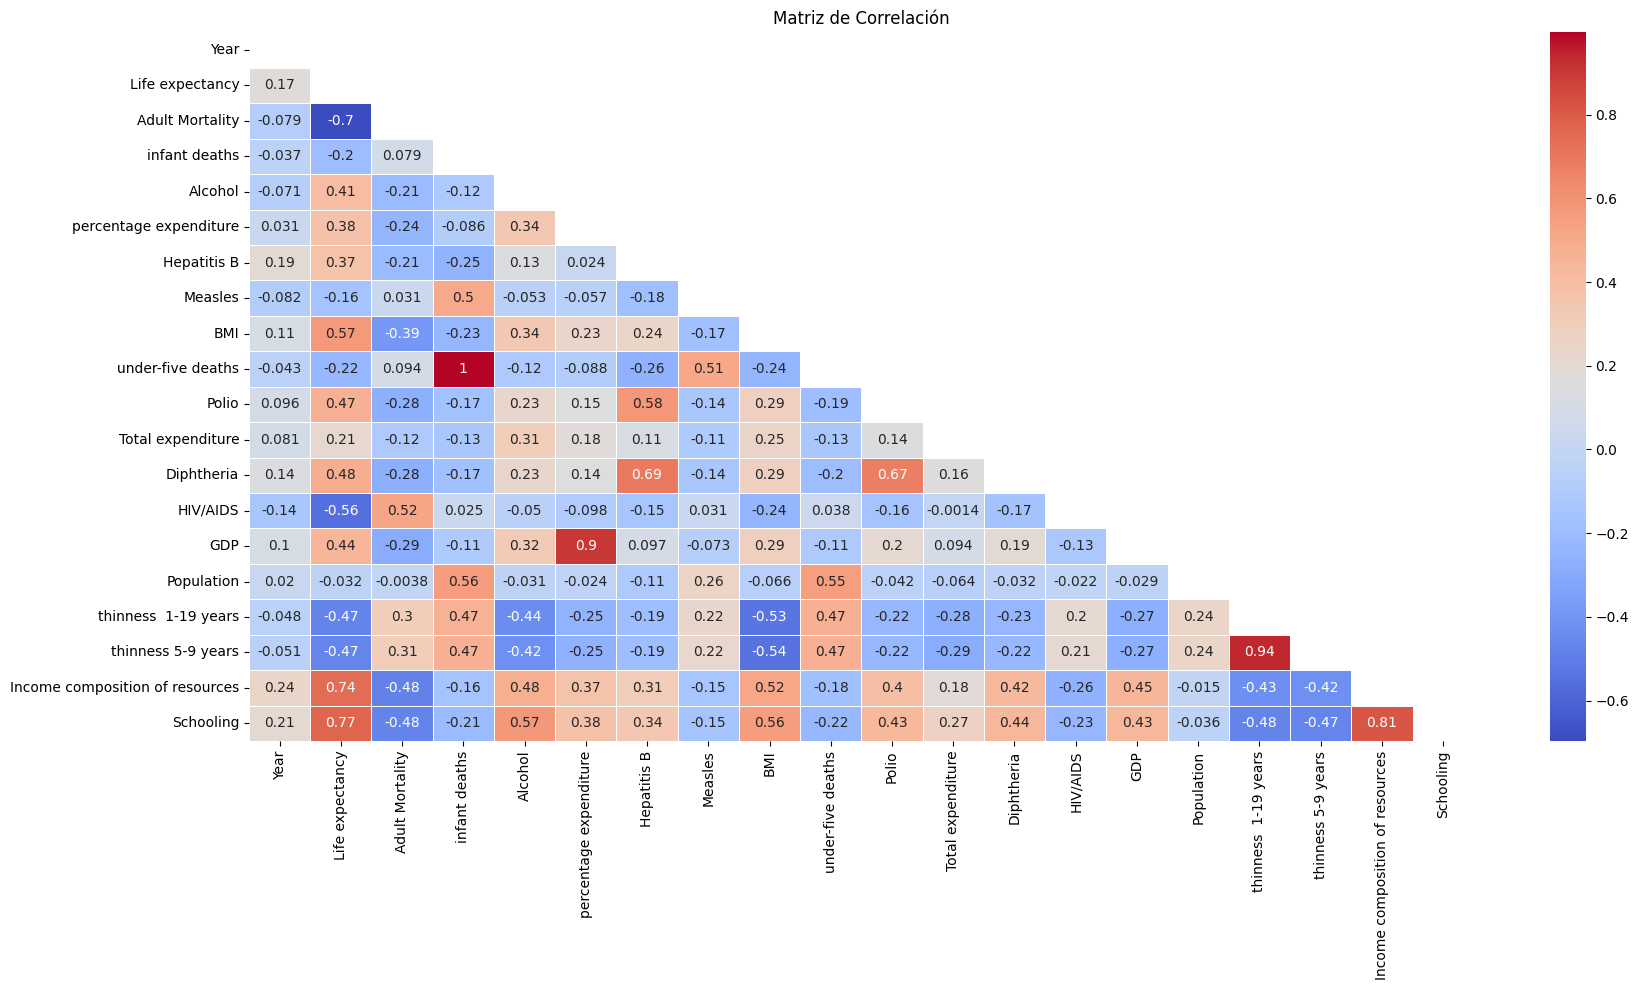

In [169]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


numerical_cols = df_imputed.select_dtypes(include=np.number).columns.tolist()
corr = df_imputed[numerical_cols].corr()

# Matriz de correlación

plt.figure(figsize=(18, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Se puede observar que tenemos datos que estan muy correlacionados, lo que provoca multicolinealidad es decir, esas variables dicen practicamente lo mismo, con lo cual lo suyo es eliminar alguna de esas variables y de esta forma reducir el tamaño del dataset.

Las columnas que vamos a eliminar en este caso van a ser:
- Year
- Country
- Thinness 5-9 years
- Under-five deaths
- Percentage expenditure

In [170]:
cols_to_drop = ['Year', 'Country', 'thinness 5-9 years', 'under-five deaths','percentage expenditure']

df_reduced = df_imputed.drop(columns=cols_to_drop)
print(df_reduced.shape)

(2938, 17)


## 2. Encoding variables categóricas

Vamos a codificar la variable Status mediante el método OneHotEncoding. En este caso, vamos a tener 0 para los 'Developing' y 1 para los 'Developed'. 

In [171]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop="first", # para evitar la multicolinealidad, eliminamos una categoría
                    sparse_output=False, # para obtener un DataFrame en lugar de una matriz dispersa
                    categories=[["Developing", "Developed"]]) # especificamos las categorías para asegurar el orden correcto. 0 = Developing, 1 = Developed

status_encoded = pd.DataFrame(
    ohe.fit_transform(df_reduced[["Status"]]),
    columns=["Status_Developed"]
)

df_reduced = df_reduced.drop(columns=["Status"]).reset_index(drop=True)
df_reduced = pd.concat([df_reduced, status_encoded], axis=1)

print(ohe.get_feature_names_out())
df_reduced.head()


['Status_Developed']


,Life expectancy,Adult Mortality,infant deaths,Alcohol,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,Income composition of resources,Schooling,Status_Developed
0,65.0,263.0,62.0,0.01,65.0,1154.0,19.1,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,0.479,10.1,0.0
1,59.9,271.0,64.0,0.01,62.0,492.0,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,0.476,10.0,0.0
2,59.9,268.0,66.0,0.01,64.0,430.0,18.1,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,0.470,9.9,0.0
3,59.5,272.0,69.0,0.01,67.0,2787.0,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,0.463,9.8,0.0
4,59.2,275.0,71.0,0.01,68.0,3013.0,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,0.454,9.5,0.0


## 3. Selección de features (variables)

Para este escenario tenemos varias opciones, podemos seleccionar las variables directamente o emplear un PCA para reducir el tamaño del dataset. En este caso, lo que vamos hacer es seleccioanr las variables de forma directa, en caso de emplear un PCA lo haremos mas adelante cuando hagamos variaciones del modelo.

In [172]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Separamos el target
X = df_reduced.drop(columns=["Life expectancy",'Income composition of resources','Diphtheria','Polio', 'Hepatitis B', 'Schooling'])

# Calculamos VIF para cada variable
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] # calculamos el VIF para cada variable y lo almacenamos en el DataFrame

print(vif.sort_values("VIF", ascending=False).to_string())

                Variable       VIF
5      Total expenditure  6.258973
4                    BMI  4.741516
2                Alcohol  3.813696
0        Adult Mortality  3.662204
9   thinness  1-19 years  2.922517
1          infant deaths  2.260673
10      Status_Developed  2.212970
7                    GDP  1.633936
6               HIV/AIDS  1.543714
8             Population  1.541994
3                Measles  1.397223


Para seleccionar las variables realizamos un VIF (Factor de Inflación de la Varianza) que es una métrica que cuantifica qué tanto se incrementa la varianza de un coeficiente de regresión debido a la correlación entre variables independientes. Un resultado mayor que 10 indica una muy alta correlación entre las variables. En nuestro modelo, las variables que muestran un valor mayor a 10 son:
- Income composition of resources
- Diphtheria
- Polio
- Hepatitis B
- Schooling

Aunque son variables que nos ayudan a explicar nuestra variable dependiente (Life expectancy) es necesario eliminarlas ya que el VIF mayor a 10 nos indicaba multicolinealidad severa y por tanto el modelo si las mantenemos pierde estabilidad.

## 4. Entrenar el modelo y evaluar con métricas

A continuación vamos a construir y evaluar el modelo con las siguientes métricas:
- $R\\^2$
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Separamos el target y las features

y = df_reduced["Life expectancy"]

X = df_reduced.drop(columns=["Life expectancy",'Income composition of resources','Diphtheria','Polio', 'Hepatitis B', 'Schooling'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Entrenamos
model = LinearRegression()
model.fit(X_train, y_train) # entrenamos el modelo con los datos de entrenamiento

# Predecimos

y_pred = model.predict(X_test) # predecimos con los datos de prueba

# Métricas

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R^2: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')


R^2: 0.7112
RMSE: 5.2060
MAE: 3.8036


El Mean Absolute Error nos indica que el modelo se equivoca de media 3.80 años al predecir la esperanza de vida

In [174]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train) # añadimos una constante para el intercepto

# Entrenamos con OLS
model_ols = sm.OLS(y_train, X_train_const).fit() # entrenamos el modelo OLS con los datos de entrenamiento

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     473.8
Date:               mi., 04 mar. 2026   Prob (F-statistic):               0.00
Time:                        13:01:36   Log-Likelihood:                -6229.1
No. Observations:                2056   AIC:                         1.248e+04
Df Residuals:                    2044   BIC:                         1.255e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   68.9194 

Desglosando el modelo completo podemos ver que tanto el R-Squared como el R-Squeared Adj son muy parejos, lo cual es una buena señal, indicando que no tenemos variables innecesarias inflando el R-Squared. Hay que recordar que esta métrica lo que hace es indicar que porcentaje de la varianza es capaz de explicar nuestro modelo.

En cuando a la probabilidad de F-Estadístico hay que tener claro que cuando la hipótesis nula $H_0: \beta_1 = \beta_2 ... = \beta_p$ podemos rechazar la hipótesis nula, por tanto los coeficientes del modelo en su conjunto son significativos, por tanto el modelo es útil. Tener en cuenta que ser útil no implica que sea el mejor.

Entrando en detalle dentro de los propios coeficientes, podemos observar que tanto 'Total expenditure' como 'Population' tiene un valor mayor que nuestro p-value del 5%. Esto nos indica que no son significativos y por tanto hay que eliminarlos del modelo.

Por otro lado, hay que tener un ojo en 'infant deaths' y 'thinness 1-19 years' ya que son significativos pero de forma justa.

Por último destacar que tenemos un **Skew** de -0.570, dentro del rango aceptable pero cona ligera cola hacia la izquierda. En cuanto a la **Kurtosis** si que se desvía del valor ideal que es 3. Este valor de 4.651 nos indica que tenemos colas más pesadas de lo normal, indicando que hay más valores extremos en nuestros residuos de lo esperado.

Ahora vamos a ajustar el modelo eliminando las variables que no son significativas

In [175]:
# Separamos el target y las features para el modelo OLS
y = df_reduced["Life expectancy"]
X = df_reduced.drop(columns=["Life expectancy",'Income composition of resources','Diphtheria','Polio', 'Hepatitis B', 'Schooling', 'Total expenditure', 'Population'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_const_2 = sm.add_constant(X_train) # añadimos una constante para el intercepto

# Entrenamos con OLS
model_ols_2 = sm.OLS(y_train, X_train_const_2).fit() # entrenamos el modelo OLS con los datos de entrenamiento

print(model_ols_2.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     577.9
Date:               mi., 04 mar. 2026   Prob (F-statistic):               0.00
Time:                        13:01:36   Log-Likelihood:                -6231.4
No. Observations:                2056   AIC:                         1.248e+04
Df Residuals:                    2046   BIC:                         1.254e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   69.2976 

El nuevo modelo presenta gran similitud con los datos del primer modelo. Ahora 'infant deaths' deja de ser significativa y tenemos que volver a ajustar el modelo.

In [176]:
# Separamos el target y las features para el modelo OLS
y = df_reduced["Life expectancy"]
X = df_reduced.drop(columns=["Life expectancy",'Income composition of resources','Diphtheria','Polio', 'Hepatitis B', 'Schooling', 'Total expenditure', 'Population','infant deaths'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_const_3 = sm.add_constant(X_train) # añadimos una constante para el intercepto

# Entrenamos con OLS
model_ols_3 = sm.OLS(y_train, X_train_const_3).fit() # entrenamos el modelo OLS con los datos de entrenamiento

print(model_ols_3.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     649.3
Date:               mi., 04 mar. 2026   Prob (F-statistic):               0.00
Time:                        13:01:36   Log-Likelihood:                -6232.7
No. Observations:                2056   AIC:                         1.248e+04
Df Residuals:                    2047   BIC:                         1.253e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   69.3855 

Aunque el modelo es robusto y por tanto válido, vamos a tratar de solucionar nuestro problema de Kurtosis. Antes de solucionar este problema vamos a explicar el significado de nuestros coeficientes.

- Adult Mortality: por cada unidad adicional de mortalidad adulta, la esperanza de vida baja 0.027 años.
- Alcohol: por cada unidad adicional de consumo de alcohol, la esperanza de vida aumenta 0.28 años. De primeras parace contradictorio pero puede venir explicado porque los países con mayor consumo de alcohol son países más desarrollados. (Importante tener en cuenta posibles factores como la religión)
- Measless (Sarampión): el efecto por unidad es prácticamente nulo. Puede ser más relevante el efecto acumulado que el propio efecto individual.
- BMI: por cada unidad la esperanza de vida aumenta 0.097 años de vida. Cierta similitud con el alcohol.
- HIV/AIDS: por cada unidad adicional de muertes por esta enfermdad, la esperanza de vida baja 0.50 años.
- GDP: pasa como el sarampión, el efecto acumulado puede ser más significativo.
- Thinness: por cada unidad adicional de delgadez extrema, la esperanza de vida se reduce 0.12 años.
- Status_developed: ser un país desarrollado tiene un efecto muy positivo ya que añade 2.56 años de vida.

Ahora que entendemos como funciona el valor de nuestros coeficientes vamos a intentar tratar esos residuos con valores atípicos.

## Predicción

In [178]:
# Añadir constante al test (igual que hiciste con train)
X_test_const_3 = sm.add_constant(X_test)

# Predecir
y_train_pred = model_ols_3.predict(X_train_const_3) # Residuo
y_test_pred = model_ols_3.predict(X_test_const_3) # Error

# Evaluar


print("TRAIN")
print(f"R2:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred):.4f}")
print(f'MAE: {mean_absolute_error(y_train, y_train_pred):.4f}')
print('')
print("TEST")
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.4f}")
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.4f}')

TRAIN
R2:   0.7173
RMSE: 5.0155
MAE: 3.7464

TEST
R2:   0.7083
RMSE: 5.2323
MAE: 3.8225


## 5. Evaluar residuos

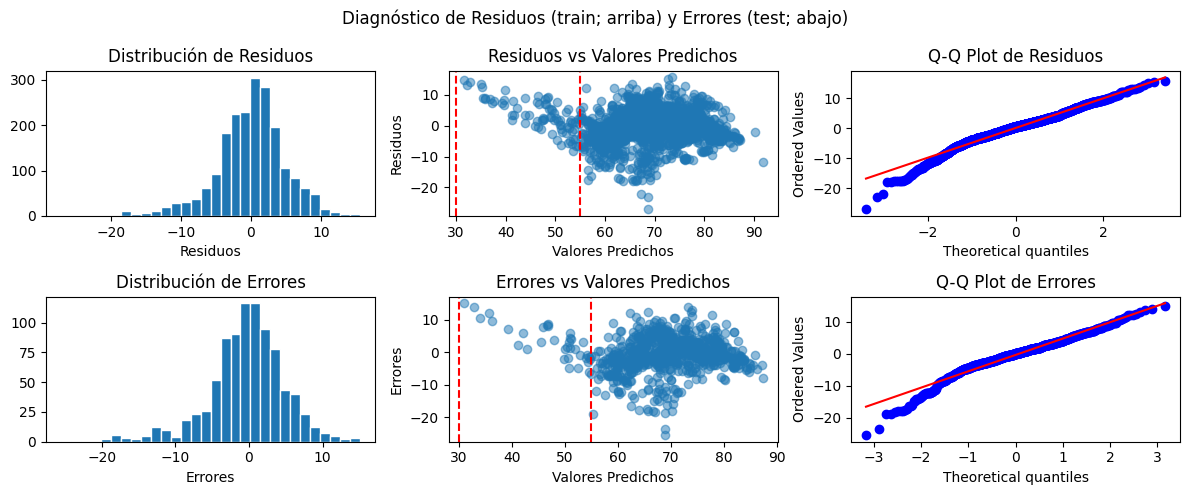

In [179]:
import scipy.stats as stats

# Obtenemos los residuos del modelo OLS

residuos = model_ols_3.resid # conjunto de entrenamienot
errores = y_test - y_test_pred # conjunto de validación

fig, ax = plt.subplots(2, 3, figsize=(12, 5))
fig.suptitle('Diagnóstico de Residuos (train; arriba) y Errores (test; abajo)')

# Histograma de residuos
ax[0,0].hist(residuos, bins=30, ec='white')
ax[0,0].set_title('Distribución de Residuos')
ax[0,0].set_xlabel('Residuos')

# Residuos vs Predichos
ax[0,1].scatter(model_ols_3.fittedvalues, residuos, alpha=0.5)
ax[0,1].set_xlabel('Valores Predichos')
ax[0,1].set_ylabel('Residuos')
ax[0,1].set_title('Residuos vs Valores Predichos')
ax[0,1].axvline(30, color='red', linestyle='--')
ax[0,1].axvline(55, color='red', linestyle='--')

# Q-Q Plot
stats.probplot(residuos, dist="norm", plot=ax[0,2])
ax[0,2].set_title('Q-Q Plot de Residuos')


# Histograma de Errores
ax[1,0].hist(errores, bins=30, ec='white')
ax[1,0].set_title('Distribución de Errores')
ax[1,0].set_xlabel('Errores')

# Errores vs Predichos
ax[1,1].scatter(y_test_pred.ravel(), errores, alpha=0.5)
ax[1,1].set_xlabel('Valores Predichos')
ax[1,1].set_ylabel('Errores')
ax[1,1].set_title('Errores vs Valores Predichos')
ax[1,1].axvline(30, color='red', linestyle='--')
ax[1,1].axvline(55, color='red', linestyle='--')

# Q-Q Plot
stats.probplot(errores, dist="norm", plot=ax[1,2])
ax[1,2].set_title('Q-Q Plot de Errores')

plt.tight_layout()
plt.show()

En el histograma podemos ver que los residuos se encuentran más bien centrados en el 0. Se puede apreciar que tenemos una cola izquerda un poco más larga. 

En cuanto al gráfico de puntos, aquí es donde se muestra de forma más clara nuestra problemática. Los valores que se encuentran entre 30 y 50 muestran esa dispersión que nos genera problemas. Esto nos indica la presencia de heterocedasticidad, es decir, que la varianza de los residuos no es constante a lo largo del modelo. El modelo se equivoca principalmente en los países donde la esperanza de vida es baja.

Por último con el Q-Q Plot podemos observar como se desvían nuestros datos al principio. Los puntos alejados son los valores atípicos. Lo ideal es que los puntos sigan sin desviarse mucho la linea roja.

Alguna forma de arreglar este problema es aplicar una transformación logarítmica a nuestra variable dependiente y comprobar si arregla el problema. Otra opción es intentar identificar a donde corresponden esos valores atípicos.

En este caso lo que vamos hacer es aplicar la transformación logarítmica.

**IMPORTANTE**: aunque la transformación no arregle nuestro problema el modelo sigue siendo válido ya que es consistente y robusto.

Vamos a aplicar un test de Normalidad antes de la transformación

In [180]:
stat, p_value = stats.shapiro(residuos)
print(f'Statisitc: {stat:.4f}, p-value: {p_value:.4f}')

Statisitc: 0.9749, p-value: 0.0000


En este caso, el test de normalidad confirma lo que hemos observado en los gráficos. Nuestros residuos no siguen una distribución normal.

p-valor > 0.05 --> no se rechaza normalidad
p-valor < 0.05 --> se rechaza la normalidad.


Hay que tener en cuenta que el test de Shapiro es muy sensible al tamaño muestral. Con muestras grandes como esta casi siempre se rechaza H0. Podemos concluir con que el test rechaza la normalidad estricta, pero visualmente, los residuos visualmente muestran una distribución aproximadamente normal. 

Procedamos con la transformación logarítmica

In [181]:
# Aplicamos log a la variable objetivo

y_log = np.log(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.3,
    random_state=42
)

X_train_const_log = sm.add_constant(X_train) # añadimos una constante para el intercepto
model_ols_log = sm.OLS(y_train_log, X_train_const_log).fit() # entrenamos el modelo OLS con los datos de entrenamiento
print(model_ols_log.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     644.5
Date:               mi., 04 mar. 2026   Prob (F-statistic):               0.00
Time:                        13:01:36   Log-Likelihood:                 2340.7
No. Observations:                2056   AIC:                            -4663.
Df Residuals:                    2047   BIC:                            -4613.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.2308 

Tras la transformación logarítmica, en vez de mejorar, los resultados empeoran. Este peor resultado nos lleva a quedarnos con el tercer modelo ejecutado. Los outliers que nos encontramos son valores puntuales.

# VAMOS A REALIZAR LA REGRESIÓN PARA UN AÑO CONCRETO

Hasta ahora nuestro modelo estaba trabajando con los datos a nivel general, lo que puede provocar problemas de independencia. Ahora vamos a seleccionar un año para nuestros datos y trabajar a partir de ese año.

Vamos a rescatar el dataset en donde no hemos aplicado ninguna transformación salvo la imputación mediante MICE. En esta ocasión vamos a probar a crear el modelo solo para los datos del año 2015.

In [182]:
df_imputed.head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status,Country
0,2015.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,...,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Developing,Afghanistan
1,2014.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,...,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Developing,Afghanistan
2,2013.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,...,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,Developing,Afghanistan
3,2012.0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,93.0,...,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,Developing,Afghanistan
4,2011.0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,97.0,...,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,Developing,Afghanistan


## 1. EDA

Tal como ya mencionamos, vamos aplicar un EDA para los datos del año 2015. En esta ocasión el EDA se limita solo a la matriz de correlaciones ya que salvando los descriptivios lo demás ya está realizado.

In [183]:
df_imputed_2015 = df_imputed[df_imputed['Year'] == 2015] # aplicamos un filtro para quedarnos con los datos del año 2015
df_imputed_2015

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status,Country
0,2015.0,65.0,263.0,62.0,0.010000,71.279624,65.0,1154.0,19.1,83.0,...,65.0,0.1,584.259210,3.373649e+07,17.2,17.3,0.479,10.1,Developing,Afghanistan
16,2015.0,77.8,74.0,0.0,4.600000,364.975229,99.0,0.0,58.0,0.0,...,99.0,0.1,3954.227830,2.887300e+04,1.2,1.3,0.762,14.2,Developing,Albania
32,2015.0,75.6,19.0,21.0,3.738739,0.000000,95.0,63.0,59.5,24.0,...,95.0,0.1,4132.762920,3.987153e+07,6.0,5.8,0.743,14.4,Developing,Algeria
48,2015.0,52.4,335.0,66.0,2.444739,0.000000,64.0,118.0,23.3,98.0,...,64.0,1.9,3695.793748,2.785935e+06,8.3,8.2,0.531,11.4,Developing,Angola
64,2015.0,76.4,13.0,0.0,3.908244,0.000000,99.0,0.0,47.7,0.0,...,99.0,0.2,13566.954100,7.753828e+06,3.3,3.3,0.784,13.9,Developing,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2858,2015.0,74.1,157.0,9.0,5.001395,0.000000,87.0,0.0,62.1,10.0,...,87.0,0.1,4627.203071,1.147691e+07,1.6,1.5,0.769,14.3,Developing,Venezuela (Bolivarian Republic of)
2874,2015.0,76.0,127.0,28.0,1.399574,0.000000,97.0,256.0,17.5,35.0,...,97.0,0.1,4672.835452,1.435883e+07,14.2,14.5,0.678,12.6,Developing,Viet Nam
2890,2015.0,65.7,224.0,37.0,-0.896590,0.000000,69.0,468.0,41.3,47.0,...,69.0,0.1,2930.775746,1.620415e+07,13.6,13.4,0.499,9.0,Developing,Yemen
2906,2015.0,61.8,33.0,27.0,2.656162,0.000000,9.0,9.0,23.4,40.0,...,9.0,4.1,1313.889646,1.615870e+05,6.3,6.1,0.576,12.5,Developing,Zambia


Vamos a crear la matriz de correlaciones para ver como se comportan los datos

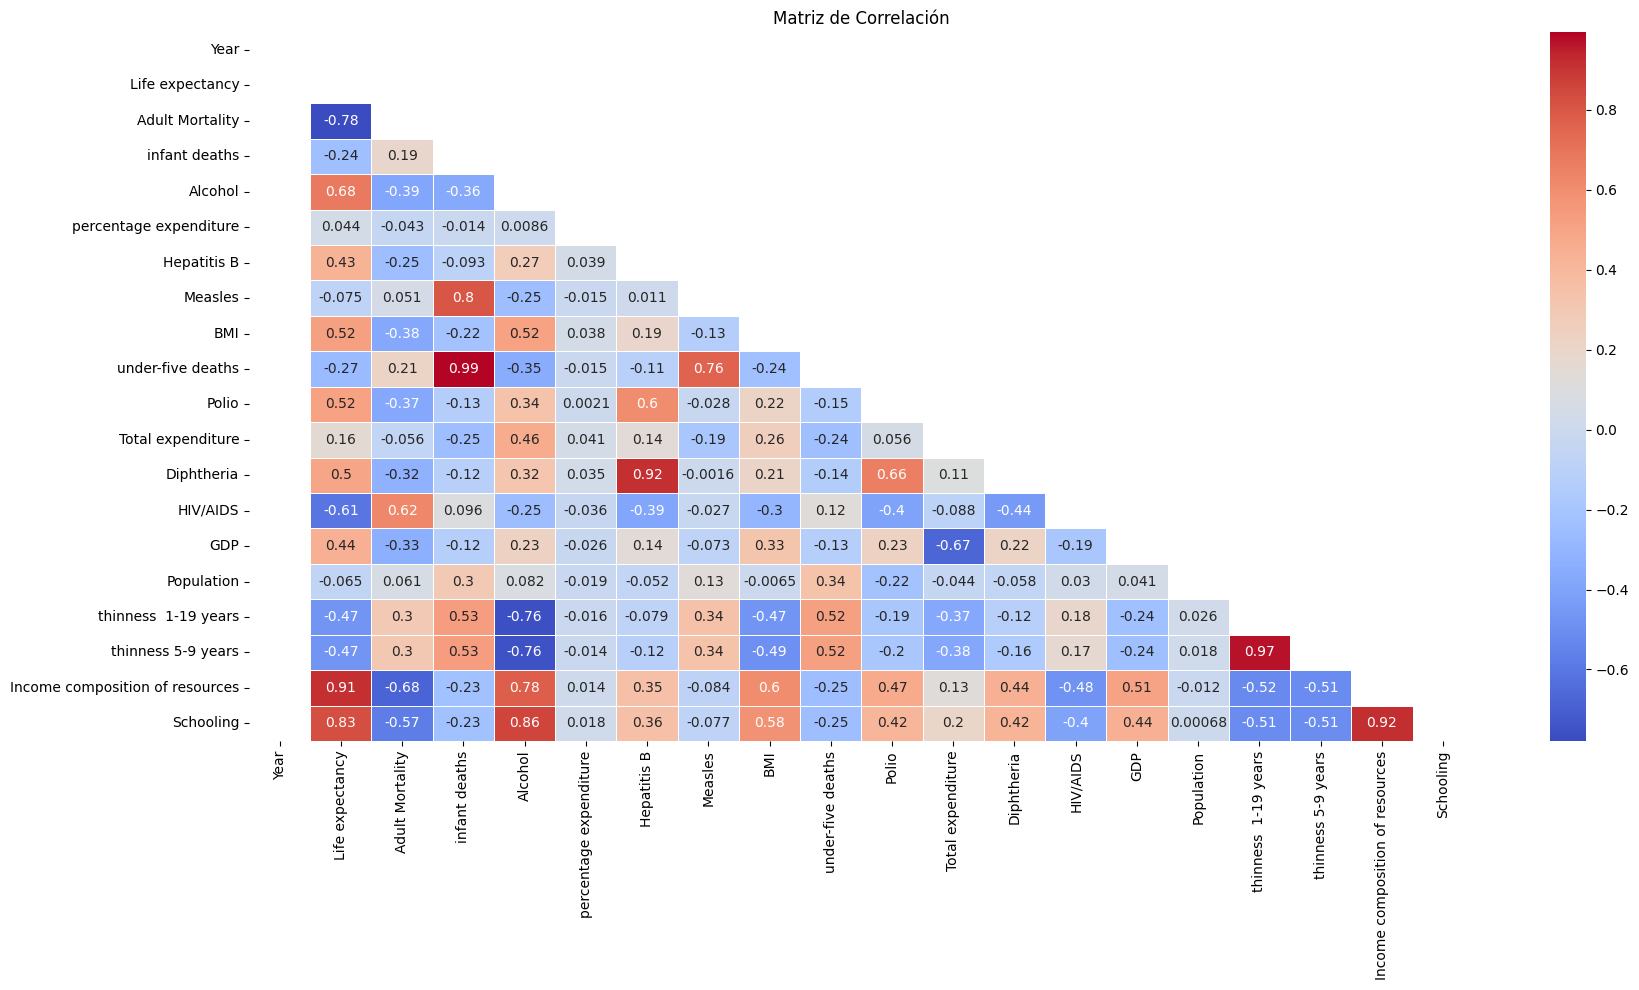

In [184]:
numerical_cols = df_imputed_2015.select_dtypes(include=np.number).columns.tolist()
corr_2015 = df_imputed_2015[numerical_cols].corr()

# Matriz de correlación

plt.figure(figsize=(18, 10))
mask = np.triu(np.ones_like(corr_2015, dtype=bool))
sns.heatmap(corr_2015, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Para los datos del año 2015 podemos ver que las relaciones entre las variables son mucho más intensas que cuando tratamos los datos a nivel general. Para nuestro modelo vamos a eliminar una vez más aquellas variables que tienen una correlación mayor a 0.8. Este paso lo ejecutaremos en el módulo 3, junto el cálculo VIF

## 2. Encoding variables categóricas

Vamos a aplicar un OneHotEncoding a la variable Status, tal como hicimos anteriormente. El proceso va a seguir con este nuevo modelo va a ser prácticamente idéntico a lo que ya hemos realizado. 

In [185]:
ohe = OneHotEncoder(drop="first", # para evitar la multicolinealidad, eliminamos una categoría
                    sparse_output=False, # para obtener un DataFrame en lugar de una matriz dispersa
                    categories=[["Developing", "Developed"]]) # especificamos las categorías para asegurar el orden correcto. 0 = Developing, 1 = Developed

status_encoded_2015 = pd.DataFrame(
    ohe.fit_transform(df_imputed_2015[["Status"]]),
    columns=["Status_Developed"]
)

df_imputed_2015 = df_imputed_2015.drop(columns=["Status"]).reset_index(drop=True)
df_imputed_2015 = pd.concat([df_imputed_2015, status_encoded_2015], axis=1)

print(ohe.get_feature_names_out())
df_imputed_2015.head()

['Status_Developed']


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Country,Status_Developed
0,2015.0,65.0,263.0,62.0,0.010000,71.279624,65.0,1154.0,19.1,83.0,...,65.0,0.1,584.259210,3.373649e+07,17.2,17.3,0.479,10.1,Afghanistan,0.0
1,2015.0,77.8,74.0,0.0,4.600000,364.975229,99.0,0.0,58.0,0.0,...,99.0,0.1,3954.227830,2.887300e+04,1.2,1.3,0.762,14.2,Albania,0.0
2,2015.0,75.6,19.0,21.0,3.738739,0.000000,95.0,63.0,59.5,24.0,...,95.0,0.1,4132.762920,3.987153e+07,6.0,5.8,0.743,14.4,Algeria,0.0
3,2015.0,52.4,335.0,66.0,2.444739,0.000000,64.0,118.0,23.3,98.0,...,64.0,1.9,3695.793748,2.785935e+06,8.3,8.2,0.531,11.4,Angola,0.0
4,2015.0,76.4,13.0,0.0,3.908244,0.000000,99.0,0.0,47.7,0.0,...,99.0,0.2,13566.954100,7.753828e+06,3.3,3.3,0.784,13.9,Antigua and Barbuda,0.0


## 3. Selección de features

In [186]:
# Separamos el target
X_2015 = df_imputed_2015.drop(columns=['Year', 'Country', 'thinness 5-9 years', 'under-five deaths',
                                       'percentage expenditure','Income composition of resources', 'Diphtheria', 'Schooling', 'Life expectancy',
                                       'Total expenditure', 'Hepatitis B', 'Polio'])

# Calculamos VIF para cada variable
vif = pd.DataFrame()
vif["Variable"] = X_2015.columns
vif["VIF"] = [variance_inflation_factor(X_2015.values, i) for i in range(X_2015.shape[1])] # calculamos el VIF para cada variable y lo almacenamos en el DataFrame

# Secuencia de la compresión de lista
# X_2015.shape[1] es el número de columnas que tiene la variable independiente.
# i es el índice de cada columna
# variance_inflation_factor(X_2015.values, i) calcula el VIF para la columna i de X_2015

print(vif.sort_values("VIF", ascending=False).to_string())

               Variable       VIF
2               Alcohol  6.739244
4                   BMI  6.678629
0       Adult Mortality  5.305097
1         infant deaths  4.452285
8  thinness  1-19 years  3.260540
3               Measles  3.182431
5              HIV/AIDS  2.066235
9      Status_Developed  1.907113
6                   GDP  1.742413
7            Population  1.466116


## 4. Entrenar y evaluar métricas

In [187]:
# Separamos el target y las features

y_2015 = df_imputed_2015["Life expectancy"]

X_2015 = df_imputed_2015.drop(columns=['Year', 'Country', 'thinness 5-9 years', 'under-five deaths',
                                       'percentage expenditure','Income composition of resources', 'Diphtheria', 'Schooling', 'Life expectancy',
                                       'Total expenditure', 'Hepatitis B', 'Polio'])


X_train, X_test, y_train, y_test = train_test_split(
    X_2015,
    y_2015,
    test_size=0.3,
    random_state=42
)

# Entrenamos
model_2015 = LinearRegression()
model_2015.fit(X_train, y_train) # entrenamos el modelo con los datos de entrenamiento

# Predecimos

y_pred_2015= model_2015.predict(X_test) # predecimos con los datos de prueba

# Métricas

r2_2015 = r2_score(y_test, y_pred_2015)
rmse_2015 = root_mean_squared_error(y_test, y_pred_2015)
mae_2015 = mean_absolute_error(y_test, y_pred_2015)

print(f'R^2: {r2_2015:.4f}')
print(f'RMSE: {rmse_2015:.4f}')
print(f'MAE: {mae_2015:.4f}')


R^2: 0.8165
RMSE: 3.4522
MAE: 2.6144


In [188]:
model_ols_2015 = sm.OLS(y_train, sm.add_constant(X_train)).fit() # entrenamos el modelo OLS con los datos de entrenamiento

print(model_ols_2015.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     57.54
Date:               mi., 04 mar. 2026   Prob (F-statistic):           1.87e-40
Time:                        13:01:37   Log-Likelihood:                -335.90
No. Observations:                 128   AIC:                             693.8
Df Residuals:                     117   BIC:                             725.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   66.5038 

Analizando los datos para nuestro primer modelo con datos solo del año 2015, tenemos lo siguiente:
- $R\\^2$: 0.831. Es un resultado inicial bastante bueno. Mejora de forma sustancial el modelo más general.
- Adj. $R\\^2$: 0.817. Este resultado también resulta ser muy bueno. Hay que tener presente que el r-squared ajustado penaliza más el modelo cuando tiene variables que están inflando el modelo.
- Prob (F-statistic): 1.87e-40. Tenemos un valor muy cercano a cero lo que nos permite rechazar la hipótesis nula, es decir, que todos los coeficientes son igual a 0, indicando que ninguna variable explica nada. NO ES NUESTRO CASO

En cuanto a los P-Values:
- infant deaths: 0.914. No es estadísticamente significativo, lo vamos a eliminar de nuestro modelo ya que es mayor que 0.05.
- Measles (sarampión): 0.471. Tampoco es estadísticamente significativa, pero vamos a eliminar datos uno a uno por si se corrige antes de ser eliminada.
- Status_developed: 0.805. Llama la atención este resultado, lo que se puede explicar que sea poco relevante al medir los datos unicamente por un año y por tanto no se puede apreciar una mejoría de los mismos en comparación a otros años.


**IMPORTANTE**: tener en cuenta que cada vez que eliminamos una variable hay que volver a entrenar el modelo.

In [189]:
# Separamos el target y las features

y_2015 = df_imputed_2015["Life expectancy"]

X_2015 = df_imputed_2015.drop(columns=['Year', 'Country', 'thinness 5-9 years', 'under-five deaths',
                                       'percentage expenditure','Income composition of resources', 'Diphtheria', 'Schooling', 'Life expectancy',
                                       'Total expenditure', 'Hepatitis B', 'Polio', 'infant deaths', 'Measles','Status_Developed'])


X_train, X_test, y_train, y_test = train_test_split(
    X_2015,
    y_2015,
    test_size=0.3,
    random_state=42
)

model_ols_2015_2 = sm.OLS(y_train, sm.add_constant(X_train)).fit() # entrenamos el modelo OLS con los datos de entrenamiento

print(model_ols_2015_2.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     83.11
Date:               mi., 04 mar. 2026   Prob (F-statistic):           5.41e-43
Time:                        13:01:37   Log-Likelihood:                -336.66
No. Observations:                 128   AIC:                             689.3
Df Residuals:                     120   BIC:                             712.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   66.0127 

Observando los coeficientes de las variables, podemos observar que la variable HIV/AIDS y Adult Mortality reducen la esperanza de vida. Aunque la variable Populatión también resulta negativa, no la vamos a tener en cuenta porque su efecto es insignificante. En general, se puede observar que los efectos que tienen las variables son muy pequeños. Lo más probable es que esto se deba a trabajar con datos para un solo año, en donde no se va a notar mucha diferencia.

## Predicción

In [190]:
# Añadir constante al test (igual que hiciste con train)
X_test_const_2015 = sm.add_constant(X_test)
X_train_const_2015 = sm.add_constant(X_train)
# Predecir
y_train_pred_2015 = model_ols_2015_2.predict(X_train_const_2015) # Residuo
y_test_pred_2015 = model_ols_2015_2.predict(X_test_const_2015) # Error

# Evaluar


print("TRAIN")
print(f"R2:   {r2_score(y_train, y_train_pred_2015):.4f}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred_2015):.4f}")
print(f'MAE: {mean_absolute_error(y_train, y_train_pred_2015):.4f}')
print('')
print("TEST")
print(f"R2:   {r2_score(y_test, y_test_pred_2015):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_2015):.4f}")
print(f'MAE: {mean_absolute_error(y_test, y_test_pred_2015):.4f}')

TRAIN
R2:   0.8290
RMSE: 3.3576
MAE: 2.5659

TEST
R2:   0.7998
RMSE: 3.6057
MAE: 2.7282


## 4. Evaluación residuos

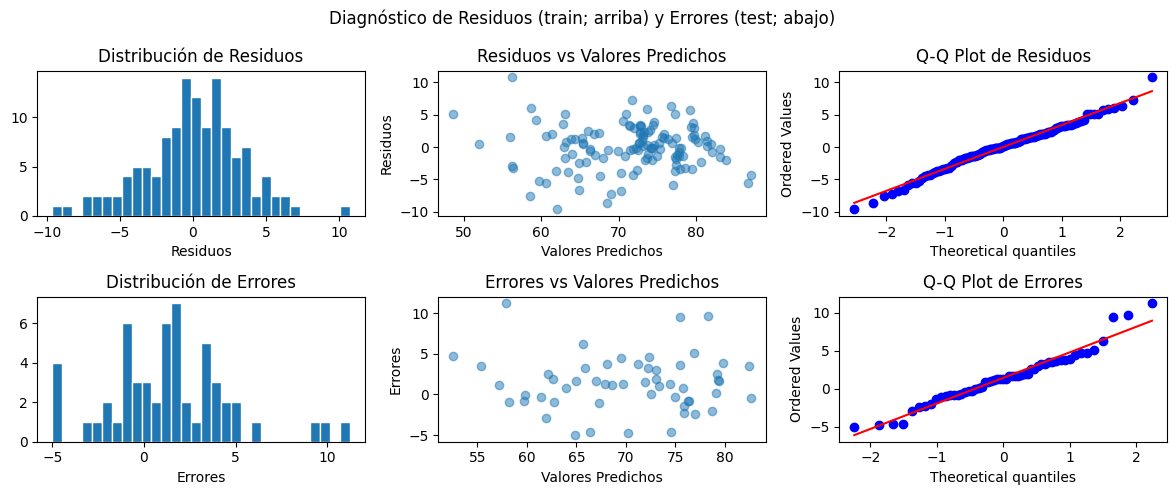

In [191]:
import scipy.stats as stats

# Obtenemos los residuos del modelo OLS

residuos_2015 = model_ols_2015_2.resid
errores_2015 = y_test - y_test_pred_2015

fig, ax = plt.subplots(2, 3, figsize=(12, 5))
fig.suptitle('Diagnóstico de Residuos (train; arriba) y Errores (test; abajo)')

# Histograma de residuos
ax[0,0].hist(residuos_2015, bins=30, ec='white')
ax[0,0].set_title('Distribución de Residuos')
ax[0,0].set_xlabel('Residuos')

# Residuos vs Predichos
ax[0,1].scatter(model_ols_2015_2.fittedvalues, residuos_2015, alpha=0.5)
ax[0,1].set_xlabel('Valores Predichos')
ax[0,1].set_ylabel('Residuos')
ax[0,1].set_title('Residuos vs Valores Predichos')


# Q-Q Plot
stats.probplot(residuos_2015, dist="norm", plot=ax[0,2])
ax[0,2].set_title('Q-Q Plot de Residuos')


# Histograma de errores
ax[1,0].hist(errores_2015, bins=30, ec='white')
ax[1,0].set_title('Distribución de Errores')
ax[1,0].set_xlabel('Errores')

# Errores vs Predichos
ax[1,1].scatter(y_test_pred_2015.ravel(), errores_2015, alpha=0.5)
ax[1,1].set_xlabel('Valores Predichos')
ax[1,1].set_ylabel('Errores')
ax[1,1].set_title('Errores vs Valores Predichos')


# Q-Q Plot
stats.probplot(errores_2015, dist="norm", plot=ax[1,2])
ax[1,2].set_title('Q-Q Plot de Errores')

plt.tight_layout()
plt.show()

In [192]:
stats.shapiro(residuos_2015)

ShapiroResult(statistic=0.9894397854804993, pvalue=0.43684688210487366)

En este caso, como la muestra es más pequeña el test de Shapiro es menos sensible. No podemos rechazar H0, no tenemos evidencia suficiente para decir que los residuos no son normales. Graficamente también podemos comprobar que siguen cierta normalidad.